# 量子退火 (Quantum Annealing) 實作課程

**課程時長**：3 小時  
**工具**：D-Wave Ocean SDK (`dwave-ocean-sdk`)  
**先備知識**：Simulated Annealing 理論、Python 基礎、Linux 環境操作

---

| 時段 | 主題 | 時長 |
|:---|:---|:---|
| Part 1 | 量子退火理論回顧 & QUBO 介紹 | 30 min |
| Part 2 | QUBO 實作：3 變數範例 + 16 變數習題 | 40 min |
| Part 3 | 應用：倉儲最佳化問題 | 40 min |
| — | ☕ 休息 | 10 min |
| Part 4 | QPU 硬體架構：Pegasus & Zephyr | 30 min |
| Part 5 | Embedding 與 QPU 實作 | 30 min |

---
## Part 0：環境設定
Run in terminal
```
conda env create -f dwave_env.yml
```
首先安裝 D-Wave Ocean SDK。這個套件包含了我們需要的所有工具：
- `dimod`：定義與操作 Binary Quadratic Model (BQM)
- `dwave-samplers`：包含 Simulated Annealing Sampler（本機端求解）
- `dwave-system`：連接 D-Wave QPU 硬體

In [77]:
import dimod
import numpy as np
import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler

print(f"dimod version: {dimod.__version__}")
print("環境設定完成！")

dimod version: 0.12.21
環境設定完成！


---
## Part 1：量子退火理論回顧 & QUBO 介紹

### 1.1 從 Simulated Annealing 到 Quantum Annealing

在之前的理論課程中，我們學過 **Simulated Annealing (SA)**：
- 模擬金屬退火過程，利用**熱擾動**跳脫局部最小值
- 溫度 $T$ 逐漸降低，系統最終凍結在（接近）全域最小值
- Metropolis-Hastings 準則：$P(\text{accept}) = \min(1, e^{-\Delta E / k_B T})$

**Quantum Annealing (QA)** 的核心想法類似，但利用的是**量子穿隧效應 (quantum tunneling)**：

$$H(s) = (1 - s)\, H_{\text{driver}} + s\, H_{\text{problem}}$$

其中：
- $s \in [0, 1]$ 是退火參數，從 0 緩慢增加到 1
- $H_{\text{driver}}$（初始 Hamiltonian）：所有 qubit 處於疊加態，系統有大量量子擾動
- $H_{\text{problem}}$（問題 Hamiltonian）：編碼我們要最佳化的目標函數

根據**絕熱定理 (Adiabatic Theorem)**，如果退火過程夠慢，系統會一直停留在瞬時基態，
最終到達 $H_{\text{problem}}$ 的基態——也就是我們要找的最佳解。

#### SA vs QA 能量地景比較

| | Simulated Annealing | Quantum Annealing |
|:---|:---|:---|
| 跳脫機制 | 熱擾動（翻越能障） | 量子穿隧（穿越能障） |
| 控制參數 | 溫度 $T$ | 退火參數 $s$（橫場強度） |
| 變數類型 | 連續或離散 | 離散（qubit: $\{0,1\}$ 或 $\{-1,+1\}$） |
| 硬體 | 傳統 CPU | D-Wave 量子退火機 |

**重點**：在深且窄的能量谷中，量子穿隧可能比熱跳躍更有效率。

### 1.2 QUBO 模型（Quadratic Unconstrained Binary Optimization）

量子退火機解決的問題必須寫成 **QUBO** 格式：

$$\min_{x \in \{0,1\}^n} \; f(x) = \sum_{i} Q_{ii}\, x_i + \sum_{i < j} Q_{ij}\, x_i x_j = x^T Q\, x$$

其中：
- $x_i \in \{0, 1\}$ 是二元變數
- $Q$ 是上三角矩陣
- 因為 $x_i^2 = x_i$（二元變數性質），線性項可以放在 $Q$ 的對角線上

#### 等價的 Ising 模型

D-Wave 硬體原生使用 **Ising 模型**（$s_i \in \{-1, +1\}$）：

$$H_{\text{Ising}} = \sum_i h_i\, s_i + \sum_{i<j} J_{ij}\, s_i s_j$$

QUBO 與 Ising 可以透過變換 $x_i = (s_i + 1)/2$ 互相轉換。
D-Wave 的 `dimod` 套件會自動處理這個轉換，所以我們只需要用 QUBO 思考即可。

#### 約束處理：Penalty Method

QUBO 是「**無約束**」的格式，但現實問題常有約束。
解法：將約束轉為 **penalty term**，加入目標函數中。

| 約束類型 | 數學形式 | Penalty 項 |
|:---|:---|:---|
| 等式 | $\sum x_i = k$ | $\lambda(\sum x_i - k)^2$ |
| One-hot | $\sum x_i = 1$ | $\lambda(\sum x_i - 1)^2$ |
| 不等式 | $\sum x_i \leq k$ | 需引入 slack variables |

**範例**：若要求 $x_1 + x_2 + x_3 = 1$（三選一），penalty 為：

$$P = \lambda(x_1 + x_2 + x_3 - 1)^2$$

展開後（利用 $x_i^2 = x_i$）：

$$P = \lambda(-x_1 - x_2 - x_3 + 2x_1 x_2 + 2x_1 x_3 + 2x_2 x_3 + 1)$$

當且僅當恰好一個變數為 1 時，$P = 0$（不影響目標函數）。

---
## Part 2：QUBO 實作 — SimulatedAnnealingSampler

### 2.1 範例：2 變數 QUBO

我們來解一個簡單的 QUBO 問題：

$$\min\; H = -x_1 - x_2 + 2 x_1 x_2 $$

**步驟**：
1. 將問題寫成 QUBO 字典格式
2. 建構 BQM (Binary Quadratic Model)
3. 用 SimulatedAnnealingSampler 求解
4. 用暴力法驗證

In [78]:
# 定義 QUBO: H = -x1 - x2 + 2 x1*x2
Q = {
    ('x1', 'x1'):  -1,   # x1 的線性係數
    ('x2', 'x2'):  -1,   # x2 的線性係數
    ('x1', 'x2'): 2,   # x1*x2 的耦合係數
}

# 建構 BQM
import dimod
from dwave.samplers import SimulatedAnnealingSampler
bqm = dimod.BinaryQuadraticModel.from_qubo(Q)
print("QUBO 矩陣（字典格式）：")
for k, v in Q.items():
    print(f"  {k}: {v}")

QUBO 矩陣（字典格式）：
  ('x1', 'x1'): -1
  ('x2', 'x2'): -1
  ('x1', 'x2'): 2


In [79]:
# 建立 SA sampler 並求解
sampler = SimulatedAnnealingSampler()
result = sampler.sample_qubo(Q, num_reads=100, num_sweeps=1000)

# 顯示最佳解
print("最佳解：")
best = result.first
print(f"  變數值: {best.sample}")
print(f"  能量值: {best.energy}")

最佳解：
  變數值: {'x1': np.int8(1), 'x2': np.int8(0)}
  能量值: -1.0


### 2.2 習題：16 變數 QUBO（子集選擇問題）

有 16 件貨物，每件有**重量** $w_i$ 和**價值** $v_i$。
選出一個子集使得：**總價值最大化**，且**總重量不超過容量** $W$。

$$\min\; -\sum_i v_i x_i + \lambda \left(\sum_i w_i x_i - W\right)^2$$

In [80]:
import numpy as np
# 問題資料：16 件貨物
np.random.seed(42)
n_items = 16
weights = np.random.randint(1, 10, size=n_items)
values  = np.random.randint(5, 30, size=n_items)
capacity = int(np.sum(weights) * 0.4)

# TODO: 建構 16 變數的 QUBO
lam = 2.0  # penalty 係數
Q_knapsack = {}

for i in range(n_items):
    xi = f'x{i}'
    Q_knapsack[(xi, xi)] = -values[i] + lam * (weights[i]**2 - 2 * capacity * weights[i])
    for j in range(i+1, n_items):
        xj = f'x{j}'
        Q_knapsack[(xi, xj)] = lam * 2 * weights[i] * weights[j]

print(f"QUBO 建立完成，非零項數量: {len(Q_knapsack)}")

QUBO 建立完成，非零項數量: 136


In [81]:
import dimod
from dwave.samplers import SimulatedAnnealingSampler

# 轉為 BQM 並求解
bqm = dimod.BinaryQuadraticModel.from_qubo(Q_knapsack)
sampler = SimulatedAnnealingSampler()
result = sampler.sample(bqm, num_reads=500, num_sweeps=2000)

print('=== 16變數 QUBO 退火求解結果 ===')
best = result.first
min_energy = best.energy
selected = [i for i in range(n_items) if best.sample[f'x{i}'] == 1]
total_w = sum(weights[i] for i in selected)
total_v = sum(values[i] for i in selected)
status = '✅ 合法' if total_w <= capacity else '❌ 爆了'

print(f'最低能量: {min_energy}')
print(f'最佳解選取索引: {selected}')
print(f'總重量: {total_w} / 容量限制: {capacity}')
print(f'總價值: {total_v}')
print(f'此解找到的次數: {best.num_occurrences} / {len(result)}')
print(f'狀態: {status}')


=== 16變數 QUBO 退火求解結果 ===
最低能量: -2766.0
最佳解選取索引: [0, 1, 4, 8, 9, 12, 14, 15]
總重量: 37 / 容量限制: 36
總價值: 176
此解找到的次數: 1 / 500
狀態: ❌ 爆了


In [82]:
import itertools

print('=== 暴力窮舉驗算 (2^16 = 65536 種組合) ===')
best_value = 0
best_combinations = []  # 儲存所有達到最大價值的組合 (combo, weight)

for combo in itertools.product([0, 1], repeat=n_items):
    total_w = sum(w * x for w, x in zip(weights, combo))
    total_v = sum(v * x for v, x in zip(values, combo))
    
    if total_w <= capacity:
        if total_v > best_value:
            best_value = total_v
            best_combinations = [(combo, total_w)]
        elif total_v == best_value:
            best_combinations.append((combo, total_w))

print(f'真正的最佳總價值: {best_value}')
print(f'共有 {len(best_combinations)} 組不同的最佳解：\n')

for idx, (combo, total_w) in enumerate(best_combinations):
    selected_indices = [i for i, x in enumerate(combo) if x == 1]
    print(f'解 {idx+1}: 選取索引 {selected_indices} | 總重量 {total_w}/{capacity}')


=== 暴力窮舉驗算 (2^16 = 65536 種組合) ===
真正的最佳總價值: 170
共有 2 組不同的最佳解：

解 1: 選取索引 [0, 4, 7, 9, 12, 14, 15] | 總重量 36/36
解 2: 選取索引 [0, 1, 8, 9, 12, 13, 14, 15] | 總重量 36/36


---
## Part 3：應用 — 倉儲最佳化問題

我們來看一個典型的**倉儲貨物分配問題 (Warehouse Item Assignment)**。
將頻繁存取的貨物放在離出貨口近的地方，以**最小化總搬運成本**。

使用 `dimod.ConstrainedQuadraticModel` (CQM) 可以直覺地加入等式與不等式約束。

In [83]:
from dimod import ConstrainedQuadraticModel, Binary

N = 4  # 貨物數量
M = 3  # 位置數量

# 貨物: [頻率 f, 體積 s]
items = {0: {'f': 50, 's': 2}, 1: {'f': 10, 's': 4}, 2: {'f': 40, 's': 5}, 3: {'f': 5, 's': 3}}
# 位置: [距離 d, 容量 C]
locations = {0: {'d': 1, 'C': 5}, 1: {'d': 3, 'C': 8}, 2: {'d': 6, 'C': 10}}

cqm = ConstrainedQuadraticModel()
x = { (i, j): Binary(f'x_{i}_{j}') for i in range(N) for j in range(M) }

# 目標函數: sum(f_i * d_j * x_ij)
objective = sum(items[i]['f'] * locations[j]['d'] * x[i, j] for i in range(N) for j in range(M))
cqm.set_objective(objective)

# 約束 1: 每件貨物只能放一個位置
for i in range(N):
    cqm.add_constraint(sum(x[i, j] for j in range(M)) == 1, label=f'item_{i}')

# 約束 2: 位置容量限制
for j in range(M):
    cqm.add_constraint(sum(items[i]['s'] * x[i, j] for i in range(N)) <= locations[j]['C'], label=f'loc_{j}')

print("CQM 模型建立完成！")

CQM 模型建立完成！


In [84]:
import dimod
from dwave.samplers import SimulatedAnnealingSampler

# 轉為 BQM 並求解
bqm, invert_mapping = dimod.cqm_to_bqm(cqm, lagrange_multiplier=100.0)
sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=100, num_sweeps=1000)

best_energy = sampleset.first.energy
best_sample = sampleset.first.sample
print(f"  能量值: {best_energy}")
print("\n--- 最佳分配結果 ---")
for i in range(N):
    for j in range(M):
        if best_sample[f'x_{i}_{j}'] == 1:
            print(f"貨物 {i} -> 位置 {j}")

  能量值: 185.0

--- 最佳分配結果 ---
貨物 0 -> 位置 0
貨物 1 -> 位置 1
貨物 3 -> 位置 0


---
## Part 4：QPU 硬體架構與 Embedding

到目前為止，我們都在本機用 CPU 跑 `SimulatedAnnealingSampler`。
現在我們要將問題送到真實的量子處理器 (Quantum Processing Unit, QPU)。

### 4.1 D-Wave 硬體拓樸 (Topology)

QPU 上的 qubit 並不是全互連的 (fully connected)。它們遵循特定的物理佈線圖（拓樸）：
- **Chimera** (早期)：2000 個 qubit，每個連線 6 個鄰居
- **Pegasus** (Advantage 系統)：約 5000 個 qubit，每個連線 15 個鄰居
- **Zephyr** (Advantage2 系統)：約 7000 個 qubit，每個連線 20 個鄰居

### 4.2 Minor Embedding

因為我們的「邏輯問題」(Logical problem) 變數之間的連線，通常不符合 QPU 的「物理連線」(Physical graph)。
這時需要做 **Minor Embedding**：
- 將一個邏輯變數映射到**多個**物理 qubit 上。
- 這些代表同一個變數的物理 qubit 稱為一個 **Chain**（鏈）。
- 我們在 chain 的 qubit 之間加上很強的耦合（**Chain Strength**），強迫它們保持相同的狀態 (0 或 1)。

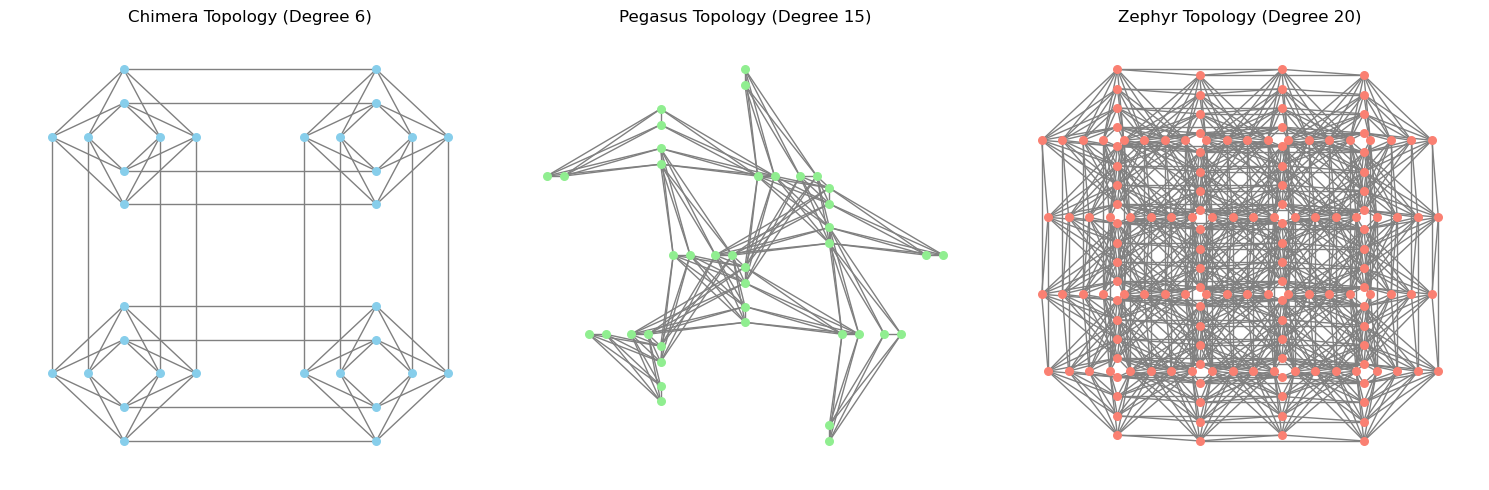

In [85]:
import dwave_networkx as dnx
import matplotlib.pyplot as plt

# 建立一個 1x3 的子圖表來並排顯示
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Chimera 拓樸 (早期 D-Wave 2000Q, 每個 qubit 連 6 個)
# 這裡畫一個 2x2 的 Chimera 晶格 (C2) 作為示意
G_chimera = dnx.chimera_graph(2)
dnx.draw_chimera(G_chimera, ax=axes[0], node_color='skyblue', node_size=30, edge_color='gray')
axes[0].set_title('Chimera Topology (Degree 6)')

# 2. Pegasus 拓樸 (Advantage 系統, 每個 qubit 連 15 個)
# 這裡畫一個規模 2 的 Pegasus 晶格 (P2) 作為示意
G_pegasus = dnx.pegasus_graph(2)
dnx.draw_pegasus(G_pegasus, ax=axes[1], node_color='lightgreen', node_size=30, edge_color='gray')
axes[1].set_title('Pegasus Topology (Degree 15)')

# 3. Zephyr 拓樸 (最新 Advantage2 系統, 每個 qubit 連 20 個)
# 這裡畫一個規模 2 的 Zephyr 晶格 (Z2) 作為示意
G_zephyr = dnx.zephyr_graph(2)
dnx.draw_zephyr(G_zephyr, ax=axes[2], node_color='salmon', node_size=30, edge_color='gray')
axes[2].set_title('Zephyr Topology (Degree 20)')

plt.tight_layout()
plt.show()


### 4.3 連線到 D-Wave Leap

請確保你已經在終端機中設定好了 API token（透過 `dwave config create` 或設定環境變數 `DWAVE_API_TOKEN`）。

連線到DWave Cloude
```
conda activate dwave_env
```
輸入
```
dwave config create
```
接著系統會出現一系列的問答提示，您只需要在問到 API Token 的時候貼上您的 Token，其他的直接按 Enter 用預設值即可。過程大致如下：

1. Configuration file path [~/.config/dwave/dwave.conf]: (按 Enter)
2. Profile (create new) [prod]: (按 Enter)
3. API endpoint URL [https://na-west-1.cloud.dwavesys.com/sapi/v2/]: (按 Enter)
4. Authentication token [None]: (在這裡貼上您的一長串 Token，然後按 Enter)
5. Client class (qpu or sw) [qpu]: (按 Enter)
6. Solver (can be left blank): (按 Enter)

設定好之後，您可以輸入 dwave ping 來測試連線是否成功。如果看到 OK，就代表大功告成了！

In [122]:
from dwave.system import DWaveSampler, EmbeddingComposite

# 建立與 QPU 的連線
try:
    qpu_sampler = DWaveSampler(solver={'topology__type': 'zephyr'})
    #qpu_sampler = DWaveSampler()
    print("✅ 成功連線至 QPU！")
    print(f"使用晶片: {qpu_sampler.properties['chip_id']}")
    print(f"拓樸架構: {qpu_sampler.properties['topology']['type']}")
    print(f"可用 Qubits 數量: {qpu_sampler.properties['num_qubits']}")
except Exception as e:
    print("❌ 連線失敗，請檢查 API token 或網路連線。")
    print(e)

✅ 成功連線至 QPU！
使用晶片: Advantage2_system1
拓樸架構: zephyr
可用 Qubits 數量: 4800


---
## Part 5：QPU 實作

我們拿 Part 2 的第一個 2 變數問題，放到 QPU 上跑。
由於需要處理 Embedding，我們不直接用 `DWaveSampler`，而是套上一層 `EmbeddingComposite`，它會在背景自動幫我們找 embedding。

In [123]:
# 回顧 Part 2 的問題
Q_simple = {
    ('x1', 'x1'):  -1, 
    ('x2', 'x2'):  -1, 
    ('x1', 'x2'): 2, 
}

try:
    # 使用 EmbeddingComposite 自動處理 embedding
    sampler_auto = EmbeddingComposite(qpu_sampler)
    
    # 提交給 QPU 求解 (num_reads=100 表示退火 100 次)
    sampleset = sampler_auto.sample_qubo(Q_simple, num_reads=100,return_embedding=True)
    
    print("--- QPU 計算結果 ---")
    print(f"最佳解: {sampleset.first.sample}")
    print(f"能量值: {sampleset.first.energy}")
    
    # 檢視實際使用的物理 Qubit (Embedding 資訊)
    embedding = sampleset.info['embedding_context']['embedding']
    print("\n--- Embedding 資訊 ---")
    for logical_var, physical_qubits in embedding.items():
        print(f"邏輯變數 {logical_var} 被映射到物理 Qubits: {physical_qubits}")
        
    print("\n--- Timing 資訊 (微秒) ---")
    timing = sampleset.info['timing']
    print(f"QPU 總時間: {timing.get('qpu_access_time', 'N/A')} us")
    print(f"純量子退火時間: {timing.get('qpu_anneal_time_per_sample', 'N/A') * 100} us")
except Exception as e:
    print("無法執行 QPU 計算:", e)

--- QPU 計算結果 ---
最佳解: {'x2': np.int8(1), 'x1': np.int8(0)}
能量值: -1.0

--- Embedding 資訊 ---
邏輯變數 x2 被映射到物理 Qubits: (411,)
邏輯變數 x1 被映射到物理 Qubits: (3002,)

--- Timing 資訊 (微秒) ---
QPU 總時間: 45795.6 us
純量子退火時間: 2000.0 us


使用 QPU 計算64變數的件貨物的大型倉儲問題

In [124]:
import numpy as np
import dimod
import networkx as nx
import matplotlib.pyplot as plt
import minorminer
from dwave.system import FixedEmbeddingComposite
import time

print("=== 建立 64 件貨物的背包問題 (Dense QUBO) ===")
n_large = 64
np.random.seed(42)
weights_large = np.random.randint(1, 10, size=n_large)
values_large  = np.random.randint(5, 30, size=n_large)
capacity_large = int(np.sum(weights_large) * 0.4)

lam_large = 15.0
Q_dense = {}
for i in range(n_large):
    xi = f'x{i}'
    Q_dense[(xi, xi)] = -values_large[i] + lam_large * (weights_large[i]**2 - 2 * capacity_large * weights_large[i])
    for j in range(i+1, n_large):
        xj = f'x{j}'
        Q_dense[(xi, xj)] = lam_large * 2 * weights_large[i] * weights_large[j]

bqm_dense = dimod.BinaryQuadraticModel.from_qubo(Q_dense)

print("\n=== 1. 獨立進行 Minor Embedding (與退火分開) ===")
start_time = time.time()

# 取得邏輯圖的連線 (BQM 的二次項)
logical_edges = list(bqm_dense.quadratic.keys())
# 取得真實硬體的實體連線
target_edges = qpu_sampler.edgelist

print(f"使用 minorminer 尋找映射到 {qpu_sampler.properties.get('chip_id', 'QPU')} 的方法...")
# 呼叫底層的 minorminer 演算法，將這個耗時的步驟獨立出來
embedding_dense = minorminer.find_embedding(logical_edges, target_edges)

embed_time = time.time() - start_time
print(f"✅ Embedding 尋找完成！耗時: {embed_time:.2f} 秒")

# 觀察其中一個邏輯變數需要幾顆實體 Qubit (Chain Length)
sample_chain = embedding_dense['x0']
print(f"舉例：邏輯變數 'x0' 被拉長成 {len(sample_chain)} 個實體 Qubits: {sample_chain}")


=== 建立 64 件貨物的背包問題 (Dense QUBO) ===

=== 1. 獨立進行 Minor Embedding (與退火分開) ===
使用 minorminer 尋找映射到 Advantage2_system1 的方法...
✅ Embedding 尋找完成！耗時: 34.59 秒
舉例：邏輯變數 'x0' 被拉長成 7 個實體 Qubits: [1832, 1833, 4362, 4363, 4364, 1797, 4233]


In [ ]:
print("\n=== 2. 使用 FixedEmbeddingComposite 進行 QPU 退火 ===")
# 這裡使用 FixedEmbeddingComposite，鎖死我們剛剛算出來的 embedding_dense
# 這樣之後無論跑幾次 sample，都不會再重新尋找 Embedding！
sampler_fixed = FixedEmbeddingComposite(qpu_sampler, embedding_dense)

print("提交給 QPU 處理...")
sampleset_dense = sampler_fixed.sample(bqm_dense, num_reads=500 )
print('=== 64變數 QUBO 退火求解結果 ===')
best = sampleset_dense.first    
min_energy = best.energy
selected = [i for i in range(n_large) if best.sample[f'x{i}'] == 1]
total_w = sum(weights_large[i] for i in selected)
total_v = sum(values_large[i] for i in selected)
status = '✅ 合法' if total_w <= capacity_large else '❌ 爆了'

print(f'最低能量: {min_energy}')
print(f'最佳解選取索引: {selected}')
print(f'總重量: {total_w} / 容量限制: {capacity_large}')
print(f'總價值: {total_v}')
print(f'此解找到的次數: {best.num_occurrences} / {len(result)}')
print(f'狀態: {status}')

#印出 Chain Break 比例 (這就是您要的指令)
break_frac = sampleset_dense.first.chain_break_fraction
print(f"最佳解的斷鏈比例 (Chain Break Fraction): {break_frac:.2%}")


=== 2. 使用 FixedEmbeddingComposite 進行 QPU 退火 ===
提交給 QPU 處理...


NameError: name 'scaled' is not defined


--- 繪製 Fixed Embedding Graph ---


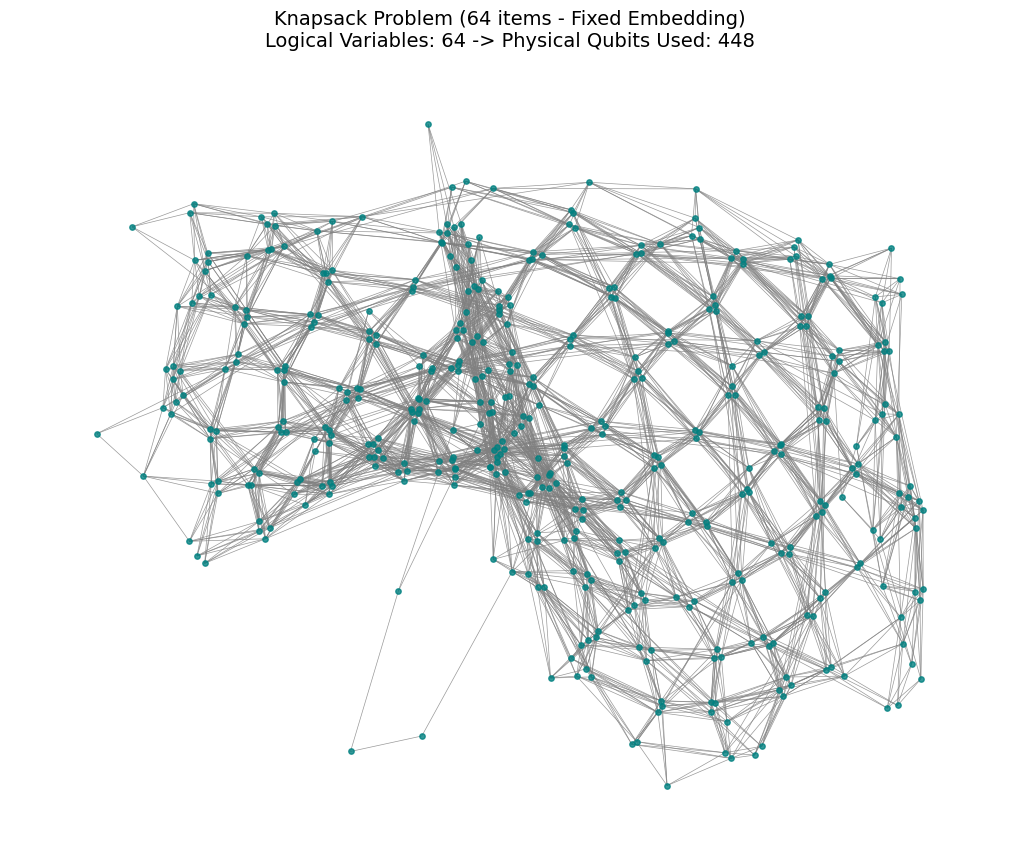

In [100]:

# 繪製我們自己獨立算出來的 Embedding Graph
print("\n--- 繪製 Fixed Embedding Graph ---")
target_graph = qpu_sampler.to_networkx_graph()
used_qubits = [q for chain in embedding_dense.values() for q in chain]
subgraph = target_graph.subgraph(used_qubits)

plt.figure(figsize=(10, 8))
nx.draw(subgraph, node_size=15, node_color='teal', edge_color='gray', width=0.5, alpha=0.8)
plt.title(f"Knapsack Problem (64 items - Fixed Embedding)\nLogical Variables: 64 -> Physical Qubits Used: {len(used_qubits)}", fontsize=14)
plt.show()

### 🎉 結語

恭喜！你已經完成了 3 小時的量子退火實作課程。
你學到了：
1. **QUBO 建模**：如何將目標函數和約束轉換成二元二次模型。
2. **SA 模擬**：如何在本機端用 Simulated Annealing 快速驗證模型。
3. **CQM 應用**：如何用高級 API 處理複雜的等式/不等式約束（如倉儲問題）。
4. **QPU 實戰**：了解 D-Wave 拓樸、Minor Embedding，並成功呼叫真實量子硬體。